# TabR tuning notebook — PCA / LDA / 4QMV

Notebook ini menjalankan 3 eksperimen TabR terpisah dari fitur apex yang sudah ada:
1. PCA
2. LDA
3. 4QMV

Prinsip:
- tidak menimpa dataset/model existing
- split train/val/external test mengikuti pipeline sekarang
- tiap mode pakai dataset + exp output baru
- evaluasi: train/val/external test + confusion matrix + kurva loss/acc


In [11]:
from __future__ import annotations

import copy
import json
import math
import os
import random
import shutil
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import Markdown, display
from scipy.special import expit
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorboard.backend.event_processing import event_accumulator

sns.set_theme(style='whitegrid')
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

TABR_ROOT = ROOT / 'third_party' / 'tabular-dl-tabr-official'
os.environ['PROJECT_DIR'] = str(TABR_ROOT)
if str(TABR_ROOT) not in sys.path:
    sys.path.append(str(TABR_ROOT))

import lib
import bin.go

FEATURES_PATH = ROOT / 'output' / 'apex' / 'features' / 'poc_abs_flatten_ordered.xlsx'
BASE_TUNING_TOML = TABR_ROOT / 'exp' / 'tabr' / 'convat_apex_anxiety' / '0-tuning.toml'
DATA_ROOT = TABR_ROOT / 'data'
EXP_ROOT = TABR_ROOT / 'exp' / 'tabr'

RANDOM_SEED = 72
N_EXTERNAL_PER_LABEL = 20
N_EVAL_SEEDS = 15
N_ENSEMBLES = 3
ENSEMBLE_SIZE = 5
RESET_MODE_OUTPUTS = True  # hanya hapus output mode baru: pca/lda/4qmv
CUDA_VISIBLE_DEVICES = os.environ.get('CUDA_VISIBLE_DEVICES', '0')
os.environ['CUDA_VISIBLE_DEVICES'] = CUDA_VISIBLE_DEVICES

LABEL_MAP = {'anxiety_rendah': 0, 'anxiety_tinggi': 1}
LABEL_NAMES = ['anxiety_rendah', 'anxiety_tinggi']
META_COLS = [
    'phase', 'condition', 'label', 'participant', 'participant_raw', 'question', 'question_no',
    'sample', 'clip', 'event_clip', 'event_no', 'clip_path', 'frame', 'target', 'event_id',
]

display(Markdown(f'- ROOT: `{ROOT}`\n- FEATURES: `{FEATURES_PATH}`\n- BASE_TUNING_TOML: `{BASE_TUNING_TOML}`'))


- ROOT: `/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st`
- FEATURES: `/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/features/poc_abs_flatten_ordered.xlsx`
- BASE_TUNING_TOML: `/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/third_party/tabular-dl-tabr-official/exp/tabr/convat_apex_anxiety/0-tuning.toml`

In [2]:
if not FEATURES_PATH.exists():
    raise FileNotFoundError(FEATURES_PATH)
if not BASE_TUNING_TOML.exists():
    raise FileNotFoundError(BASE_TUNING_TOML)

df_raw = pd.read_excel(FEATURES_PATH)
df_raw = df_raw[df_raw['label'].isin(LABEL_MAP)].copy()
df_raw['target'] = df_raw['label'].map(LABEL_MAP).astype(int)
df_raw['event_id'] = (
    df_raw['phase'].astype(str) + '||'
    + df_raw['participant'].astype(str) + '||'
    + df_raw['question'].astype(str) + '||'
    + df_raw['clip'].astype(str) + '||'
    + df_raw['event_clip'].astype(str)
)
BASE_FEATURE_COLS = [c for c in df_raw.columns if c not in META_COLS[:-2]]
BASE_FEATURE_COLS = [c for c in BASE_FEATURE_COLS if c not in {'target', 'event_id'}]

print('rows:', len(df_raw))
print('feature cols:', len(BASE_FEATURE_COLS))
print(df_raw['label'].value_counts().to_dict())
df_raw.head(2)


rows: 57656
feature cols: 392
{'anxiety_tinggi': 35980, 'anxiety_rendah': 21676}


,phase,condition,label,participant,participant_raw,question,question_no,sample,clip,event_clip,...,mata_kanan_x23,mata_kanan_y23,mata_kanan_t23,mata_kanan_m23,mata_kanan_x24,mata_kanan_y24,mata_kanan_t24,mata_kanan_m24,target,event_id
0,before,anxiety,anxiety_tinggi,aaisyah_nursalsabiil_ni_patriarti,aaisyah_nursalsabiil_ni_patriarti_1765168488512,q1,1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00095,...,0,0,0.0,0.0,0,0,0.0,0.0,1,before||aaisyah_nursalsabiil_ni_patriarti||q1|...
1,before,anxiety,anxiety_tinggi,aaisyah_nursalsabiil_ni_patriarti,aaisyah_nursalsabiil_ni_patriarti_1765168488512,q1,1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00095,...,0,0,0.0,0.0,0,0,0.0,0.0,1,before||aaisyah_nursalsabiil_ni_patriarti||q1|...


In [3]:
def balanced_external_events(event_table: pd.DataFrame, n_per_label: int, seed: int = RANDOM_SEED) -> set[str]:
    rng = random.Random(seed)
    selected_ids: list[str] = []
    for label_name in LABEL_NAMES:
        label_df = event_table[event_table['label'] == label_name].copy()
        picked_rows = []
        used_ids = set()
        participant_groups = []
        for participant, part_df in label_df.groupby('participant', sort=True):
            part_df = part_df.sort_values(['phase', 'question', 'clip', 'event_clip'], kind='stable')
            phase_groups = []
            for _phase, phase_df in part_df.groupby('phase', sort=True):
                phase_groups.append(phase_df.to_dict('records'))
            participant_groups.append((participant, phase_groups))
        while len(picked_rows) < n_per_label:
            progress = False
            for _participant, phase_groups in participant_groups:
                for records in phase_groups:
                    while records and records[0]['event_id'] in used_ids:
                        records.pop(0)
                    if not records:
                        continue
                    row = records.pop(0)
                    picked_rows.append(row)
                    used_ids.add(row['event_id'])
                    progress = True
                    if len(picked_rows) >= n_per_label:
                        break
                if len(picked_rows) >= n_per_label:
                    break
            if not progress:
                break
        if len(picked_rows) < n_per_label:
            remaining = label_df[~label_df['event_id'].isin(used_ids)].sort_values(
                ['participant', 'phase', 'question', 'clip', 'event_clip'], kind='stable'
            )
            for row in remaining.to_dict('records'):
                picked_rows.append(row)
                used_ids.add(row['event_id'])
                if len(picked_rows) >= n_per_label:
                    break
        selected_ids.extend([row['event_id'] for row in picked_rows[:n_per_label]])
    return set(selected_ids)


def balance_train_clips_by_label(df_train: pd.DataFrame, seed: int = RANDOM_SEED) -> pd.DataFrame:
    rng = random.Random(seed)
    event_table_train = (
        df_train[['event_id', 'label', 'target', 'phase', 'participant', 'question', 'clip', 'event_clip']]
        .drop_duplicates()
        .reset_index(drop=True)
    )
    grouped = {}
    for label_name, label_df in event_table_train.groupby('label', sort=True):
        clip_table = (
            label_df[['participant', 'question', 'clip', 'label']]
            .drop_duplicates()
            .sort_values(['participant', 'question', 'clip'], kind='stable')
            .reset_index(drop=True)
        )
        grouped[label_name] = clip_table
    min_clip_count = min(len(x) for x in grouped.values())
    selected_clip_keys = []
    for _label_name, clip_table in grouped.items():
        clip_records = clip_table.to_dict('records')
        rng.shuffle(clip_records)
        chosen = clip_records[:min_clip_count]
        selected_clip_keys.extend([
            (row['participant'], row['question'], row['clip'], row['label'])
            for row in chosen
        ])
    selected_clip_keys = set(selected_clip_keys)
    return df_train[
        df_train.apply(
            lambda row: (row['participant'], row['question'], row['clip'], row['label']) in selected_clip_keys,
            axis=1,
        )
    ].copy()


event_table = df_raw[['event_id', 'label', 'target', 'phase', 'participant', 'question', 'clip', 'event_clip']].drop_duplicates().reset_index(drop=True)
external_event_ids = balanced_external_events(event_table, N_EXTERNAL_PER_LABEL, seed=RANDOM_SEED)
df_external_base = df_raw[df_raw['event_id'].isin(external_event_ids)].copy()
df_train_all_base = df_raw[~df_raw['event_id'].isin(external_event_ids)].copy()
df_train_balanced_base = balance_train_clips_by_label(df_train_all_base, seed=RANDOM_SEED)
train_event_table_balanced = df_train_balanced_base[['event_id', 'label', 'target']].drop_duplicates().reset_index(drop=True)
train_event_ids, val_event_ids = train_test_split(
    train_event_table_balanced['event_id'],
    test_size=0.3,
    stratify=train_event_table_balanced['target'],
    random_state=RANDOM_SEED,
)
train_event_ids = set(train_event_ids.tolist())
val_event_ids = set(val_event_ids.tolist())

df_train_base = df_train_balanced_base[df_train_balanced_base['event_id'].isin(train_event_ids)].copy()
df_val_base = df_train_balanced_base[df_train_balanced_base['event_id'].isin(val_event_ids)].copy()

print('train rows:', len(df_train_base))
print('val rows:', len(df_val_base))
print('external rows:', len(df_external_base))
print('train events:', df_train_base['event_id'].nunique())
print('val events:', df_val_base['event_id'].nunique())
print('external events:', df_external_base['event_id'].nunique())


train rows: 34360
val rows: 14532
external rows: 906
train events: 1652
val events: 708
external events: 40


In [4]:
def make_4qmv_from_flat(df: pd.DataFrame, feature_cols: list[str]) -> tuple[pd.DataFrame, list[str]]:
    groups: dict[str, dict[str, list[str]]] = {}
    for col in feature_cols:
        if '_' not in col:
            continue
        region, rest = col.rsplit('_', 1)
        feature_type = rest[0]
        block_id = rest[1:]
        if feature_type not in {'x', 'y', 't', 'm'}:
            continue
        try:
            block_no = int(block_id)
        except ValueError:
            continue
        quadrant = f'Q{((block_no - 1) % 4) + 1}'
        groups.setdefault(region, {}).setdefault(f'{quadrant}_{feature_type}', []).append(col)

    out = df[META_COLS].copy()
    out_cols = []
    for region in sorted(groups):
        for quadrant in ['Q1', 'Q2', 'Q3', 'Q4']:
            for feature_type in ['x', 'y', 't', 'm']:
                key = f'{quadrant}_{feature_type}'
                cols = groups[region].get(key, [])
                out_col = f'{region}_{quadrant}_{feature_type}'
                if cols:
                    out[out_col] = df[cols].sum(axis=1)
                else:
                    out[out_col] = 0.0
                out_cols.append(out_col)
    return out, out_cols


def build_mode_dataframe(mode: str, df_source: pd.DataFrame, base_feature_cols: list[str]) -> tuple[pd.DataFrame, list[str], dict]:
    meta = {'mode': mode}
    if mode == '4qmv':
        df_mode, feature_cols = make_4qmv_from_flat(df_source, base_feature_cols)
        meta['n_components'] = len(feature_cols)
        return df_mode, feature_cols, meta

    imputer = SimpleImputer(strategy='mean')
    scaler = StandardScaler()
    X_train = scaler.fit_transform(imputer.fit_transform(df_train_base[base_feature_cols]))
    X_val = scaler.transform(imputer.transform(df_val_base[base_feature_cols]))
    X_test = scaler.transform(imputer.transform(df_external_base[base_feature_cols]))

    if mode == 'pca':
        n_components = min(64, X_train.shape[1], X_train.shape[0] - 1)
        transformer = PCA(n_components=n_components, random_state=RANDOM_SEED)
        X_train_t = transformer.fit_transform(X_train)
        X_val_t = transformer.transform(X_val)
        X_test_t = transformer.transform(X_test)
        meta['explained_variance_ratio_sum'] = float(transformer.explained_variance_ratio_.sum())
        meta['n_components'] = int(n_components)
    elif mode == 'lda':
        n_components = 1
        transformer = LinearDiscriminantAnalysis(n_components=n_components)
        y_train = df_train_base['target'].to_numpy(dtype=np.int64)
        X_train_t = transformer.fit_transform(X_train, y_train)
        X_val_t = transformer.transform(X_val)
        X_test_t = transformer.transform(X_test)
        meta['n_components'] = int(n_components)
    else:
        raise ValueError(f'Unknown mode: {mode}')

    feature_cols = [f'{mode}_{i+1:03d}' for i in range(X_train_t.shape[1])]
    df_train_mode = df_train_base[META_COLS].copy()
    df_val_mode = df_val_base[META_COLS].copy()
    df_test_mode = df_external_base[META_COLS].copy()
    for i, col in enumerate(feature_cols):
        df_train_mode[col] = X_train_t[:, i]
        df_val_mode[col] = X_val_t[:, i]
        df_test_mode[col] = X_test_t[:, i]
    df_mode = pd.concat([df_train_mode, df_val_mode, df_test_mode], axis=0, ignore_index=True)
    return df_mode, feature_cols, meta


In [12]:
def export_official_dataset(df_mode: pd.DataFrame, feature_cols: list[str], dataset_name: str, reset_existing: bool = RESET_MODE_OUTPUTS) -> dict:
    out_dir = DATA_ROOT / dataset_name
    if out_dir.exists():
        if reset_existing:
            shutil.rmtree(out_dir)
        else:
            raise FileExistsError(f'Dataset dir already exists: {out_dir}')

    df_tr = df_mode[df_mode['event_id'].isin(train_event_ids)].copy()
    df_val = df_mode[df_mode['event_id'].isin(val_event_ids)].copy()
    df_test = df_mode[df_mode['event_id'].isin(external_event_ids)].copy()

    imputer = SimpleImputer(strategy='mean')
    scaler = StandardScaler()
    X_train = scaler.fit_transform(imputer.fit_transform(df_tr[feature_cols])).astype(np.float32)
    X_val = scaler.transform(imputer.transform(df_val[feature_cols])).astype(np.float32)
    X_test = scaler.transform(imputer.transform(df_test[feature_cols])).astype(np.float32)
    y_train = df_tr['target'].to_numpy(dtype=np.int64)
    y_val = df_val['target'].to_numpy(dtype=np.int64)
    y_test = df_test['target'].to_numpy(dtype=np.int64)

    out_dir.mkdir(parents=True, exist_ok=False)
    np.save(out_dir / 'X_num_train.npy', X_train)
    np.save(out_dir / 'X_num_val.npy', X_val)
    np.save(out_dir / 'X_num_test.npy', X_test)
    np.save(out_dir / 'Y_train.npy', y_train)
    np.save(out_dir / 'Y_val.npy', y_val)
    np.save(out_dir / 'Y_test.npy', y_test)
    (out_dir / 'READY').write_text('')
    (out_dir / 'info.json').write_text(json.dumps({'task_type': 'binclass', 'name': dataset_name, 'id': dataset_name}, indent=2))
    (out_dir / 'feature_cols.json').write_text(json.dumps(feature_cols, indent=2))
    df_tr.to_csv(out_dir / 'train_split.csv', index=False)
    df_val.to_csv(out_dir / 'val_split.csv', index=False)
    df_test.to_csv(out_dir / 'test_split.csv', index=False)
    return {
        'dataset_dir': out_dir,
        'df_train': df_tr,
        'df_val': df_val,
        'df_test': df_test,
        'X_train': X_train,
        'X_val': X_val,
        'X_test': X_test,
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test,
    }


def prepare_tuning_config(dataset_name: str, exp_name: str, reset_existing: bool = RESET_MODE_OUTPUTS) -> tuple[dict, Path]:
    config = lib.load_config(BASE_TUNING_TOML)
    config = copy.deepcopy(config)
    config['space']['data']['path'] = f':data/{dataset_name}'
    tuning_dir = EXP_ROOT / exp_name / '0-tuning'
    tuning_toml = tuning_dir.with_suffix('.toml')
    exp_dir = EXP_ROOT / exp_name
    if exp_dir.exists():
        if reset_existing:
            shutil.rmtree(exp_dir)
        else:
            raise FileExistsError(f'Experiment path already exists: {exp_dir}')
    elif tuning_toml.exists():
        if reset_existing:
            tuning_toml.unlink()
        else:
            raise FileExistsError(f'Experiment config already exists: {tuning_toml}')
    tuning_toml.parent.mkdir(parents=True, exist_ok=True)
    lib.dump_config(config, tuning_toml)
    return config, tuning_toml


In [6]:
def load_scalar_series(run_dir: Path, tag_dir: str, tag: str) -> pd.DataFrame:
    event_file = next((run_dir / tag_dir).glob('events.out.tfevents.*'))
    ea = event_accumulator.EventAccumulator(str(event_file))
    ea.Reload()
    scalars = ea.Scalars(tag)
    return pd.DataFrame({
        'epoch': [x.step for x in scalars],
        'value': [x.value for x in scalars],
        'wall_time': [x.wall_time for x in scalars],
    })


def collect_epoch_metrics(run_dir: Path) -> pd.DataFrame:
    checkpoint = lib.load_checkpoint(run_dir, map_location='cpu')
    rows = []
    for item in checkpoint['training_log']:
        metrics = item['metrics']
        rows.append({
            'epoch': len(rows),
            'val_loss': float(metrics['val'].get('cross-entropy', np.nan)),
            'test_loss': float(metrics['test'].get('cross-entropy', np.nan)),
            'val_acc': float(metrics['val']['score']),
            'test_acc': float(metrics['test']['score']),
        })
    epoch_df = pd.DataFrame(rows)
    train_loss = load_scalar_series(run_dir, 'loss_train', 'loss')
    epoch_df = epoch_df.merge(train_loss[['epoch', 'value']].rename(columns={'value': 'train_loss'}), on='epoch', how='left')
    return epoch_df


def infer_train_accuracy_from_predictions(run_dir: Path, y_train: np.ndarray) -> float:
    preds = lib.load_predictions(run_dir)
    train_logits = preds['train']
    train_prob = expit(train_logits)
    train_pred = (train_prob >= 0.5).astype(int)
    return float((train_pred == y_train).mean())


def make_confusion_df(y_true: np.ndarray, y_pred: np.ndarray) -> pd.DataFrame:
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    return pd.DataFrame(cm, index=['true_anxiety_rendah', 'true_anxiety_tinggi'], columns=['pred_anxiety_rendah', 'pred_anxiety_tinggi'])


def evaluate_best_run(run_dir: Path, dataset_name: str, split_info: dict) -> dict:
    config = lib.load_config(run_dir.with_suffix('.toml'))
    dataset = lib.build_dataset(**config['data'])
    preds = lib.load_predictions(run_dir)
    out = {}
    for part, y_true in [('train', split_info['y_train']), ('val', split_info['y_val']), ('test', split_info['y_test'])]:
        logits = preds[part]
        prob = expit(logits)
        pred = (prob >= 0.5).astype(int)
        out[part] = {
            'y_true': y_true,
            'prob': prob,
            'pred': pred,
            'report': classification_report(y_true, pred, target_names=LABEL_NAMES, output_dict=True),
            'cm_df': make_confusion_df(y_true, pred),
        }
    out['dataset_name'] = dataset_name
    out['dataset'] = dataset
    out['report_json'] = json.loads((run_dir / 'report.json').read_text())
    out['summary_json'] = json.loads((run_dir / 'summary.json').read_text())
    out['epoch_df'] = collect_epoch_metrics(run_dir)
    out['epoch_df']['train_acc'] = np.nan
    out['epoch_df']['best_epoch'] = int(out['report_json']['best_epoch'])
    out['final_train_acc'] = infer_train_accuracy_from_predictions(run_dir, split_info['y_train'])
    return out


def plot_training_curves(result: dict, title_prefix: str) -> None:
    epoch_df = result['epoch_df'].copy()
    best_epoch = int(result['report_json']['best_epoch'])
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epoch_df['epoch'], epoch_df['train_loss'], marker='o', label='train_loss')
    axes[0].plot(epoch_df['epoch'], epoch_df['val_loss'], marker='o', label='val_loss')
    axes[0].axvline(best_epoch, linestyle='--', color='red', label=f'best_epoch={best_epoch}')
    axes[0].set_title(f'{title_prefix} loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(epoch_df['epoch'], epoch_df['val_acc'], marker='o', label='val_acc')
    axes[1].plot(epoch_df['epoch'], epoch_df['test_acc'], marker='o', label='external_test_acc')
    axes[1].axhline(result['final_train_acc'], linestyle=':', color='green', label=f"train_acc_final={result['final_train_acc']:.3f}")
    axes[1].axvline(best_epoch, linestyle='--', color='red', label=f'best_epoch={best_epoch}')
    axes[1].set_title(f'{title_prefix} accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0, 1)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_confusions(result: dict, title_prefix: str) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, part, title in zip(axes, ['val', 'test'], ['Validation', 'External test']):
        sns.heatmap(result[part]['cm_df'], annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
        ax.set_title(f'{title_prefix} {title}')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.show()


def summarize_result(mode: str, dataset_name: str, exp_name: str, result: dict, transform_meta: dict) -> pd.DataFrame:
    rows = []
    for part, part_name in [('train', 'train'), ('val', 'val'), ('test', 'external_test')]:
        report = result[part]['report']
        rows.append({
            'mode': mode,
            'dataset_name': dataset_name,
            'exp_name': exp_name,
            'split': part_name,
            'accuracy': report['accuracy'],
            'macro_f1': report['macro avg']['f1-score'],
            'weighted_f1': report['weighted avg']['f1-score'],
            'precision_tinggi': report['anxiety_tinggi']['precision'],
            'recall_tinggi': report['anxiety_tinggi']['recall'],
            'n_components': transform_meta.get('n_components'),
            'best_epoch': result['report_json']['best_epoch'],
        })
    return pd.DataFrame(rows)


## Block 1 — PCA


In [13]:
MODE = 'pca'
DATASET_NAME = 'convat_apex_anxiety_pca'
EXP_NAME = 'convat_apex_anxiety_pca'

df_mode, feature_cols_mode, transform_meta = build_mode_dataframe(MODE, df_raw[META_COLS + BASE_FEATURE_COLS].copy(), BASE_FEATURE_COLS)
split_info = export_official_dataset(df_mode, feature_cols_mode, DATASET_NAME)
_config, tuning_toml = prepare_tuning_config(DATASET_NAME, EXP_NAME)
display(Markdown(f'Prepared `{DATASET_NAME}` and `{tuning_toml}`'))


Prepared `convat_apex_anxiety_pca` and `/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/third_party/tabular-dl-tabr-official/exp/tabr/convat_apex_anxiety_pca/0-tuning.toml`

In [14]:
# Jalankan kalau sudah siap. Akan membuat output baru, tidak menimpa existing experiment lama.
bin.go.main(tuning_toml, n_seeds=N_EVAL_SEEDS, n_ensembles=N_ENSEMBLES, ensemble_size=ENSEMBLE_SIZE, force=False)


2026-04-06 21:49:30.271 | INFO     | lib.util:start:130 - Creating the output


[>>>] exp/tabr/convat_apex_anxiety_pca/0-tuning | 2026-04-06 21:49:30.271129
--------------------------------------------------------------------------------
{'seed': 72,
 'function': 'bin.tabr.main',
 'space': {'seed': 72,
           'batch_size': 128,
           'patience': 6,
           'n_epochs': inf,
           'context_size': ['_tune_', 'int', 4, 16],
           'data': {'seed': 72,
                    'cache': True,
                    'path': ':data/convat_apex_anxiety_pca',
                    'num_policy': None,
                    'cat_policy': None,
                    'y_policy': None},
           'model': {'num_embeddings': None,
                     'd_main': ['_tune_', 'int', 96, 256],
                     'context_dropout': ['_tune_', 'uniform', 0.0, 0.35],
                     'd_multiplier': 2.0,
                     'encoder_n_blocks': ['_tune_', 'int', 0, 2],
                     'predictor_n_blocks': ['_tune_', 'int', 1, 2],
                     'mixer_normalizat

[I 2026-04-06 21:49:30,529] A new study created in memory with name: no-name-324c7eed-b0bf-4622-b64e-da17d9b773fe


  0%|          | 0/15 [00:00<?, ?it/s]

2026-04-06 21:49:30.536 | INFO     | lib.util:start:130 - Creating the output
2026-04-06 21:49:30.566 | INFO     | lib.data:build_dataset:346 - Building dataset (path: /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/third_party/tabular-dl-tabr-official/data/convat_apex_anxiety_pca)


...

(val) 0.713 (test) 0.673 (loss) 0.37025

[...] exp/tabr/convat_apex_anxiety_pca/0-evaluation/14 | 0:01:09.565830


Epoch 23: 100%|██████████| 269/269 [00:02<00:00, 96.14it/s]


(val) 0.706 (test) 0.681 (loss) 0.36320

[...] exp/tabr/convat_apex_anxiety_pca/0-evaluation/14 | 0:01:12.536460


Epoch 24: 100%|██████████| 269/269 [00:02<00:00, 95.42it/s]


(val) 0.710 (test) 0.694 (loss) 0.35922

--------------------------------------------------------------------------------
{'function': 'bin.tabr.main',
 'gpus': ['NVIDIA GeForce RTX 3050 Laptop GPU'],
 'n_parameters': 873217,
 'best_epoch': 17,
 'scores': {'train': 0.8612048894062864,
            'val': 0.7131846958436554,
            'test': 0.6644591611479028},
 'time': '0:01:15.525911'}
--------------------------------------------------------------------------------
[<<<] exp/tabr/convat_apex_anxiety_pca/0-evaluation/14 | 2026-04-06 23:33:21.463016

--------------------------------------------------------------------------------
{'function': 'bin.ensemble.main',
 'gpus': [],
 'scores': {'train': 0.920547147846333,
            'val': 0.7345169281585466,
            'test': 0.6931567328918322}}
--------------------------------------------------------------------------------
[<<<] exp/tabr/convat_apex_anxiety_pca/0-ensemble-5/0 | 2026-04-06 23:33:21.573201

----------------------------

2026-04-06 23:33:21.691 | INFO     | lib.data:build_dataset:338 - Using cached dataset: build_dataset__convat_apex_anxiety_pca__None__None__None__None__72__d10c1508d8934c1de65e6394f780722e.pickle


,0,1,accuracy,macro avg,weighted avg,cross-entropy,roc-auc,score
train,"{'precision': 0.9424445076835515, 'recall': 0....","{'precision': 0.9256304176516943, 'recall': 0....",0.932509,"{'precision': 0.9340374626676229, 'recall': 0....","{'precision': 0.9328517659229434, 'recall': 0....",0.171926,0.984458,0.932509
val,"{'precision': 0.7168081494057725, 'recall': 0....","{'precision': 0.7311964822957648, 'recall': 0....",0.725365,"{'precision': 0.7240023158507687, 'recall': 0....","{'precision': 0.7247161878583165, 'recall': 0....",0.670146,0.798941,0.725365
test,"{'precision': 0.6496815286624203, 'recall': 0....","{'precision': 0.7128378378378378, 'recall': 0....",0.690949,"{'precision': 0.6812596832501291, 'recall': 0....","{'precision': 0.6867666903415839, 'recall': 0....",0.808659,0.754925,0.690949


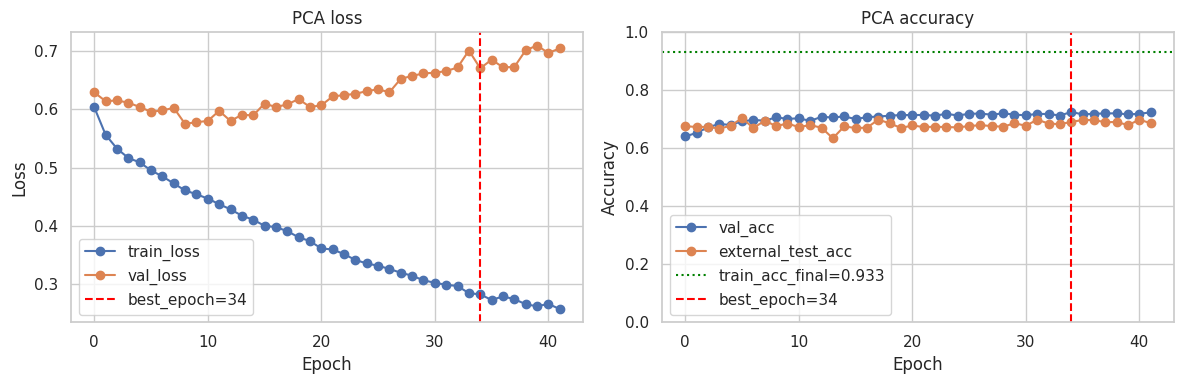

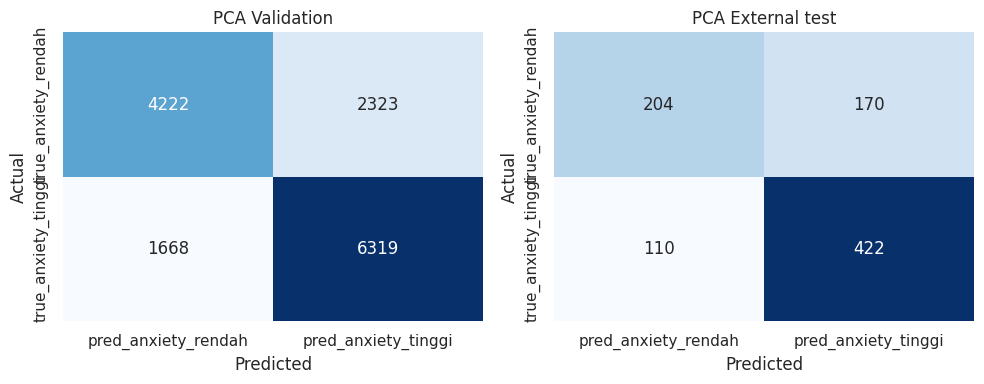

,pred_anxiety_rendah,pred_anxiety_tinggi
true_anxiety_rendah,4222,2323
true_anxiety_tinggi,1668,6319


,pred_anxiety_rendah,pred_anxiety_tinggi
true_anxiety_rendah,204,170
true_anxiety_tinggi,110,422


,mode,dataset_name,exp_name,split,accuracy,macro_f1,weighted_f1,precision_tinggi,recall_tinggi,n_components,best_epoch
0,pca,convat_apex_anxiety_pca,convat_apex_anxiety_pca,train,0.932509,0.930703,0.932280,0.925630,0.958731,64,34
1,pca,convat_apex_anxiety_pca,convat_apex_anxiety_pca,val,0.725365,0.719524,0.723540,0.731196,0.791161,64,34
2,pca,convat_apex_anxiety_pca,convat_apex_anxiety_pca,external_test,0.690949,0.671956,0.685722,0.712838,0.793233,64,34


In [15]:
EVAL_DIR = EXP_ROOT / EXP_NAME / '0-evaluation'
best_seed = max(range(N_EVAL_SEEDS), key=lambda s: json.loads((EVAL_DIR / str(s) / 'report.json').read_text())['metrics']['val']['score'])
best_run_dir = EVAL_DIR / str(best_seed)
pca_result = evaluate_best_run(best_run_dir, DATASET_NAME, split_info)
display(pd.DataFrame(pca_result['report_json']['metrics']).T)
plot_training_curves(pca_result, 'PCA')
plot_confusions(pca_result, 'PCA')
display(pca_result['val']['cm_df'])
display(pca_result['test']['cm_df'])
pca_summary = summarize_result(MODE, DATASET_NAME, EXP_NAME, pca_result, transform_meta)
display(pca_summary)


## Block 2 — LDA


In [16]:
MODE = 'lda'
DATASET_NAME = 'convat_apex_anxiety_lda'
EXP_NAME = 'convat_apex_anxiety_lda'

df_mode, feature_cols_mode, transform_meta = build_mode_dataframe(MODE, df_raw[META_COLS + BASE_FEATURE_COLS].copy(), BASE_FEATURE_COLS)
split_info = export_official_dataset(df_mode, feature_cols_mode, DATASET_NAME)
_config, tuning_toml = prepare_tuning_config(DATASET_NAME, EXP_NAME)
display(Markdown(f'Prepared `{DATASET_NAME}` and `{tuning_toml}`'))


Prepared `convat_apex_anxiety_lda` and `/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/third_party/tabular-dl-tabr-official/exp/tabr/convat_apex_anxiety_lda/0-tuning.toml`

In [17]:
bin.go.main(tuning_toml, n_seeds=N_EVAL_SEEDS, n_ensembles=N_ENSEMBLES, ensemble_size=ENSEMBLE_SIZE, force=False)


2026-04-06 23:33:27.191 | INFO     | lib.util:start:130 - Creating the output
[I 2026-04-06 23:33:27,214] A new study created in memory with name: no-name-43075373-9edc-4ab7-90cd-1282adc1984b


[>>>] exp/tabr/convat_apex_anxiety_lda/0-tuning | 2026-04-06 23:33:27.191438
--------------------------------------------------------------------------------
{'seed': 72,
 'function': 'bin.tabr.main',
 'space': {'seed': 72,
           'batch_size': 128,
           'patience': 6,
           'n_epochs': inf,
           'context_size': ['_tune_', 'int', 4, 16],
           'data': {'seed': 72,
                    'cache': True,
                    'path': ':data/convat_apex_anxiety_lda',
                    'num_policy': None,
                    'cat_policy': None,
                    'y_policy': None},
           'model': {'num_embeddings': None,
                     'd_main': ['_tune_', 'int', 96, 256],
                     'context_dropout': ['_tune_', 'uniform', 0.0, 0.35],
                     'd_multiplier': 2.0,
                     'encoder_n_blocks': ['_tune_', 'int', 0, 2],
                     'predictor_n_blocks': ['_tune_', 'int', 1, 2],
                     'mixer_normalizat

  0%|          | 0/15 [00:00<?, ?it/s]

2026-04-06 23:33:27.219 | INFO     | lib.util:start:130 - Creating the output
2026-04-06 23:33:27.242 | INFO     | lib.data:build_dataset:346 - Building dataset (path: /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/third_party/tabular-dl-tabr-official/data/convat_apex_anxiety_lda)
2026-04-06 23:33:27.252 | INFO     | bin.tabr:main:349 - n_parameters = 555789


[>>>] /tmp/tmpipa3e3x__trial_0/output | 2026-04-06 23:33:27.219534
--------------------------------------------------------------------------------
{'seed': 72,
 'data': {'seed': 72,
          'cache': True,
          'path': ':data/convat_apex_anxiety_lda',
          'num_policy': None,
          'cat_policy': None,
          'y_policy': None},
 'model': {'num_embeddings': None,
           'd_main': 206,
           'context_dropout': 0.1872369160868805,
           'd_multiplier': 2.0,
           'encoder_n_blocks': 1,
           'predictor_n_blocks': 1,
           'mixer_normalization': 'auto',
           'dropout0': 0.25574661660881326,
           'dropout1': 0.21482213648759882,
           'normalization': 'LayerNorm',
           'activation': 'ReLU'},
 'context_size': 5,
 'optimizer': {'type': 'AdamW',
               'lr': 2.1373235625915152e-05,
               'weight_decay': 1.5140333727012376e-06},
 'batch_size': 128,
 'patience': 6,
 'n_epochs': inf}
---------------------------

...

(val) 0.640 (test) 0.635 (loss) 0.58731

[...] exp/tabr/convat_apex_anxiety_lda/0-evaluation/14 | 0:00:35.377368


Epoch 20: 100%|██████████| 269/269 [00:01<00:00, 159.53it/s]


(val) 0.640 (test) 0.630 (loss) 0.58629

[...] exp/tabr/convat_apex_anxiety_lda/0-evaluation/14 | 0:00:37.164366


Epoch 21: 100%|██████████| 269/269 [00:01<00:00, 163.28it/s]


(val) 0.639 (test) 0.634 (loss) 0.58672

--------------------------------------------------------------------------------
{'function': 'bin.tabr.main',
 'gpus': ['NVIDIA GeForce RTX 3050 Laptop GPU'],
 'n_parameters': 199138,
 'best_epoch': 14,
 'scores': {'train': 0.6863795110593713,
            'val': 0.6421001926782274,
            'test': 0.6335540838852097},
 'time': '0:00:38.912224'}
--------------------------------------------------------------------------------
[<<<] exp/tabr/convat_apex_anxiety_lda/0-evaluation/14 | 2026-04-06 23:57:22.448750

--------------------------------------------------------------------------------
{'function': 'bin.ensemble.main',
 'gpus': [],
 'scores': {'train': 0.684895227008149,
            'val': 0.6401045967519956,
            'test': 0.6379690949227373}}
--------------------------------------------------------------------------------
[<<<] exp/tabr/convat_apex_anxiety_lda/0-ensemble-5/0 | 2026-04-06 23:57:22.543312

----------------------------

2026-04-06 23:57:22.632 | INFO     | lib.data:build_dataset:338 - Using cached dataset: build_dataset__convat_apex_anxiety_lda__None__None__None__None__72__d10c1508d8934c1de65e6394f780722e.pickle


,0,1,accuracy,macro avg,weighted avg,cross-entropy,roc-auc,score
train,"{'precision': 0.6516802560390155, 'recall': 0....","{'precision': 0.7078212553562179, 'recall': 0....",0.68638,"{'precision': 0.6797507556976167, 'recall': 0....","{'precision': 0.6837097091710037, 'recall': 0....",0.586822,0.744272,0.68638
val,"{'precision': 0.6150684931506849, 'recall': 0....","{'precision': 0.6602623101702715, 'recall': 0....",0.6421,"{'precision': 0.6376654016604781, 'recall': 0....","{'precision': 0.6399076767823555, 'recall': 0....",0.644385,0.684986,0.6421
test,"{'precision': 0.5561497326203209, 'recall': 0....","{'precision': 0.6879699248120301, 'recall': 0....",0.633554,"{'precision': 0.6220598287161755, 'recall': 0....","{'precision': 0.6335540838852097, 'recall': 0....",0.636824,0.686874,0.633554


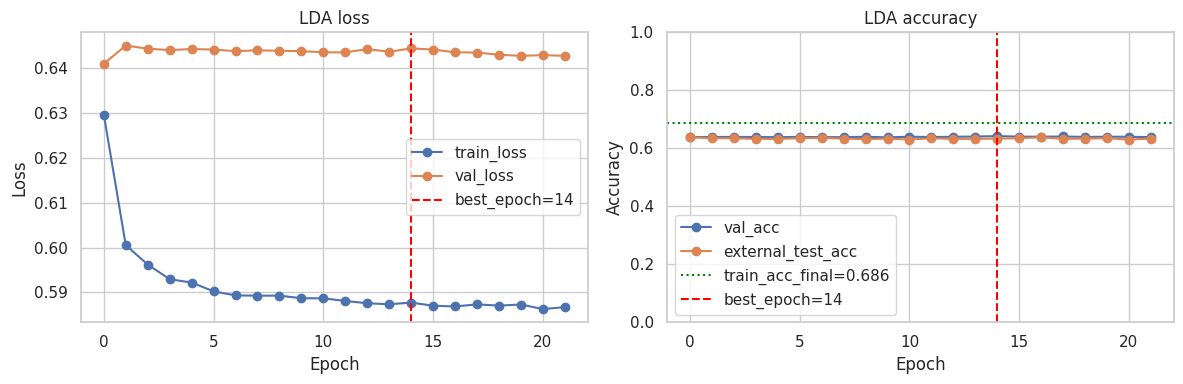

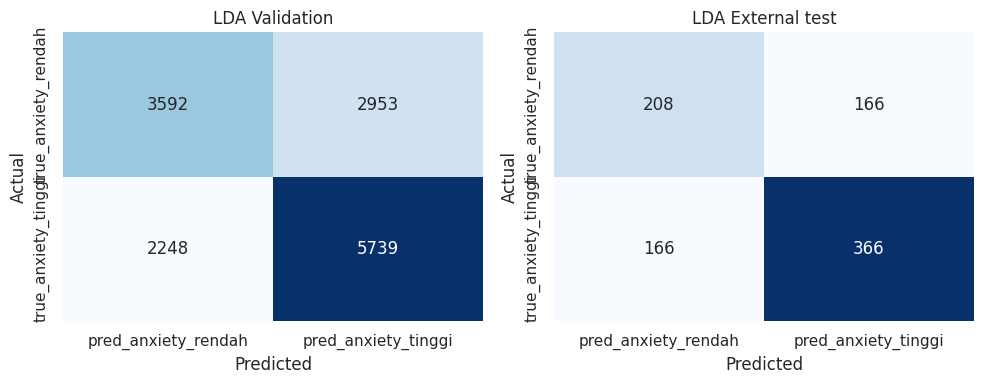

,pred_anxiety_rendah,pred_anxiety_tinggi
true_anxiety_rendah,3592,2953
true_anxiety_tinggi,2248,5739


,pred_anxiety_rendah,pred_anxiety_tinggi
true_anxiety_rendah,208,166
true_anxiety_tinggi,166,366


,mode,dataset_name,exp_name,split,accuracy,macro_f1,weighted_f1,precision_tinggi,recall_tinggi,n_components,best_epoch
0,lda,convat_apex_anxiety_lda,convat_apex_anxiety_lda,train,0.686380,0.674814,0.683463,0.707821,0.766821,1,14
1,lda,convat_apex_anxiety_lda,convat_apex_anxiety_lda,val,0.642100,0.634114,0.639478,0.660262,0.718543,1,14
2,lda,convat_apex_anxiety_lda,convat_apex_anxiety_lda,external_test,0.633554,0.622060,0.633554,0.687970,0.687970,1,14


In [18]:
EVAL_DIR = EXP_ROOT / EXP_NAME / '0-evaluation'
best_seed = max(range(N_EVAL_SEEDS), key=lambda s: json.loads((EVAL_DIR / str(s) / 'report.json').read_text())['metrics']['val']['score'])
best_run_dir = EVAL_DIR / str(best_seed)
lda_result = evaluate_best_run(best_run_dir, DATASET_NAME, split_info)
display(pd.DataFrame(lda_result['report_json']['metrics']).T)
plot_training_curves(lda_result, 'LDA')
plot_confusions(lda_result, 'LDA')
display(lda_result['val']['cm_df'])
display(lda_result['test']['cm_df'])
lda_summary = summarize_result(MODE, DATASET_NAME, EXP_NAME, lda_result, transform_meta)
display(lda_summary)


## Block 3 — 4QMV


In [19]:
MODE = '4qmv'
DATASET_NAME = 'convat_apex_anxiety_4qmv'
EXP_NAME = 'convat_apex_anxiety_4qmv'

df_mode, feature_cols_mode, transform_meta = build_mode_dataframe(MODE, df_raw[META_COLS + BASE_FEATURE_COLS].copy(), BASE_FEATURE_COLS)
split_info = export_official_dataset(df_mode, feature_cols_mode, DATASET_NAME)
_config, tuning_toml = prepare_tuning_config(DATASET_NAME, EXP_NAME)
display(Markdown(f'Prepared `{DATASET_NAME}` and `{tuning_toml}`'))


Prepared `convat_apex_anxiety_4qmv` and `/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/third_party/tabular-dl-tabr-official/exp/tabr/convat_apex_anxiety_4qmv/0-tuning.toml`

In [20]:
bin.go.main(tuning_toml, n_seeds=N_EVAL_SEEDS, n_ensembles=N_ENSEMBLES, ensemble_size=ENSEMBLE_SIZE, force=False)


2026-04-06 23:57:24.806 | INFO     | lib.util:start:130 - Creating the output
[I 2026-04-06 23:57:24,835] A new study created in memory with name: no-name-bf319f31-c7d2-4773-bdd7-d9f2a18d354e


[>>>] exp/tabr/convat_apex_anxiety_4qmv/0-tuning | 2026-04-06 23:57:24.806753
--------------------------------------------------------------------------------
{'seed': 72,
 'function': 'bin.tabr.main',
 'space': {'seed': 72,
           'batch_size': 128,
           'patience': 6,
           'n_epochs': inf,
           'context_size': ['_tune_', 'int', 4, 16],
           'data': {'seed': 72,
                    'cache': True,
                    'path': ':data/convat_apex_anxiety_4qmv',
                    'num_policy': None,
                    'cat_policy': None,
                    'y_policy': None},
           'model': {'num_embeddings': None,
                     'd_main': ['_tune_', 'int', 96, 256],
                     'context_dropout': ['_tune_', 'uniform', 0.0, 0.35],
                     'd_multiplier': 2.0,
                     'encoder_n_blocks': ['_tune_', 'int', 0, 2],
                     'predictor_n_blocks': ['_tune_', 'int', 1, 2],
                     'mixer_normaliz

  0%|          | 0/15 [00:00<?, ?it/s]

2026-04-06 23:57:24.841 | INFO     | lib.util:start:130 - Creating the output
2026-04-06 23:57:24.871 | INFO     | lib.data:build_dataset:346 - Building dataset (path: /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/third_party/tabular-dl-tabr-official/data/convat_apex_anxiety_4qmv)
2026-04-06 23:57:24.894 | INFO     | bin.tabr:main:349 - n_parameters = 565471


[>>>] /tmp/tmp8zj7ft8v_trial_0/output | 2026-04-06 23:57:24.841594
--------------------------------------------------------------------------------
{'seed': 72,
 'data': {'seed': 72,
          'cache': True,
          'path': ':data/convat_apex_anxiety_4qmv',
          'num_policy': None,
          'cat_policy': None,
          'y_policy': None},
 'model': {'num_embeddings': None,
           'd_main': 206,
           'context_dropout': 0.1872369160868805,
           'd_multiplier': 2.0,
           'encoder_n_blocks': 1,
           'predictor_n_blocks': 1,
           'mixer_normalization': 'auto',
           'dropout0': 0.25574661660881326,
           'dropout1': 0.21482213648759882,
           'normalization': 'LayerNorm',
           'activation': 'ReLU'},
 'context_size': 5,
 'optimizer': {'type': 'AdamW',
               'lr': 2.1373235625915152e-05,
               'weight_decay': 1.5140333727012376e-06},
 'batch_size': 128,
 'patience': 6,
 'n_epochs': inf}
--------------------------

...

(val) 0.621 (test) 0.640 (loss) 0.57062

[...] exp/tabr/convat_apex_anxiety_4qmv/0-evaluation/14 | 0:00:26.884027


Epoch 16: 100%|██████████| 269/269 [00:01<00:00, 176.72it/s]


(val) 0.622 (test) 0.587 (loss) 0.56799

[...] exp/tabr/convat_apex_anxiety_4qmv/0-evaluation/14 | 0:00:28.489257


Epoch 17: 100%|██████████| 269/269 [00:01<00:00, 173.65it/s]


(val) 0.622 (test) 0.619 (loss) 0.56676

--------------------------------------------------------------------------------
{'function': 'bin.tabr.main',
 'gpus': ['NVIDIA GeForce RTX 3050 Laptop GPU'],
 'n_parameters': 131419,
 'best_epoch': 10,
 'scores': {'train': 0.7059953434225844,
            'val': 0.6261354252683733,
            'test': 0.6258278145695364},
 'time': '0:00:30.119322'}
--------------------------------------------------------------------------------
[<<<] exp/tabr/convat_apex_anxiety_4qmv/0-evaluation/14 | 2026-04-07 00:40:58.357647

--------------------------------------------------------------------------------
{'function': 'bin.ensemble.main',
 'gpus': [],
 'scores': {'train': 0.7242724097788126,
            'val': 0.6350123864574732,
            'test': 0.6335540838852097}}
--------------------------------------------------------------------------------
[<<<] exp/tabr/convat_apex_anxiety_4qmv/0-ensemble-5/0 | 2026-04-07 00:40:58.475055

-------------------------

2026-04-07 00:40:58.585 | INFO     | lib.data:build_dataset:338 - Using cached dataset: build_dataset__convat_apex_anxiety_4qmv__None__None__None__None__72__d10c1508d8934c1de65e6394f780722e.pickle


,0,1,accuracy,macro avg,weighted avg,cross-entropy,roc-auc,score
train,"{'precision': 0.7212079344715286, 'recall': 0....","{'precision': 0.6925331242002725, 'recall': 0....",0.70099,"{'precision': 0.7068705293359006, 'recall': 0....","{'precision': 0.7048484377966906, 'recall': 0....",0.568276,0.759594,0.70099
val,"{'precision': 0.632026452527161, 'recall': 0.4...","{'precision': 0.6242959798019033, 'recall': 0....",0.626548,"{'precision': 0.6281612161645322, 'recall': 0....","{'precision': 0.627777671515832, 'recall': 0.6...",0.658031,0.658037,0.626548
test,"{'precision': 0.563573883161512, 'recall': 0.4...","{'precision': 0.6585365853658537, 'recall': 0....",0.628035,"{'precision': 0.6110552342636828, 'recall': 0....","{'precision': 0.6193356464867987, 'recall': 0....",0.658654,0.637153,0.628035


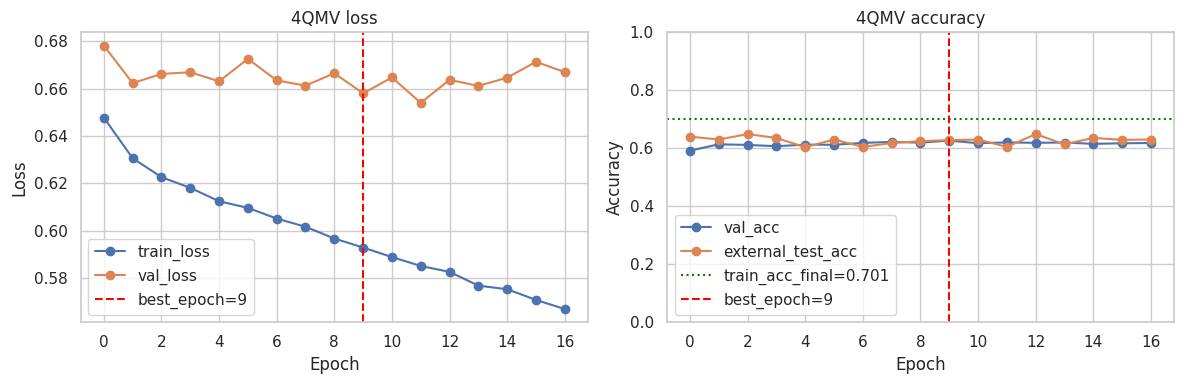

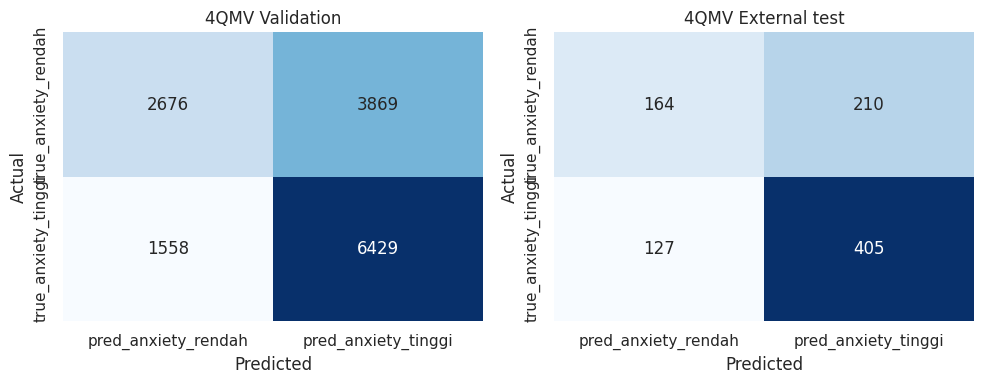

,pred_anxiety_rendah,pred_anxiety_tinggi
true_anxiety_rendah,2676,3869
true_anxiety_tinggi,1558,6429


,pred_anxiety_rendah,pred_anxiety_tinggi
true_anxiety_rendah,164,210
true_anxiety_tinggi,127,405


,mode,dataset_name,exp_name,split,accuracy,macro_f1,weighted_f1,precision_tinggi,recall_tinggi,n_components,best_epoch
0,4qmv,convat_apex_anxiety_4qmv,convat_apex_anxiety_4qmv,train,0.700990,0.676409,0.688987,0.692533,0.855889,48,9
1,4qmv,convat_apex_anxiety_4qmv,convat_apex_anxiety_4qmv,val,0.626548,0.599860,0.610114,0.624296,0.804933,48,9
2,4qmv,convat_apex_anxiety_4qmv,convat_apex_anxiety_4qmv,external_test,0.628035,0.599712,0.618281,0.658537,0.761278,48,9


In [21]:
EVAL_DIR = EXP_ROOT / EXP_NAME / '0-evaluation'
best_seed = max(range(N_EVAL_SEEDS), key=lambda s: json.loads((EVAL_DIR / str(s) / 'report.json').read_text())['metrics']['val']['score'])
best_run_dir = EVAL_DIR / str(best_seed)
qmv_result = evaluate_best_run(best_run_dir, DATASET_NAME, split_info)
display(pd.DataFrame(qmv_result['report_json']['metrics']).T)
plot_training_curves(qmv_result, '4QMV')
plot_confusions(qmv_result, '4QMV')
display(qmv_result['val']['cm_df'])
display(qmv_result['test']['cm_df'])
qmv_summary = summarize_result(MODE, DATASET_NAME, EXP_NAME, qmv_result, transform_meta)
display(qmv_summary)


## Compare all 3 modes


,mode,dataset_name,exp_name,split,accuracy,macro_f1,weighted_f1,precision_tinggi,recall_tinggi,n_components,best_epoch
2,pca,convat_apex_anxiety_pca,convat_apex_anxiety_pca,external_test,0.690949,0.671956,0.685722,0.712838,0.793233,64,34
5,lda,convat_apex_anxiety_lda,convat_apex_anxiety_lda,external_test,0.633554,0.622060,0.633554,0.687970,0.687970,1,14
8,4qmv,convat_apex_anxiety_4qmv,convat_apex_anxiety_4qmv,external_test,0.628035,0.599712,0.618281,0.658537,0.761278,48,9
0,pca,convat_apex_anxiety_pca,convat_apex_anxiety_pca,train,0.932509,0.930703,0.932280,0.925630,0.958731,64,34
6,4qmv,convat_apex_anxiety_4qmv,convat_apex_anxiety_4qmv,train,0.700990,0.676409,0.688987,0.692533,0.855889,48,9
3,lda,convat_apex_anxiety_lda,convat_apex_anxiety_lda,train,0.686380,0.674814,0.683463,0.707821,0.766821,1,14
1,pca,convat_apex_anxiety_pca,convat_apex_anxiety_pca,val,0.725365,0.719524,0.723540,0.731196,0.791161,64,34
4,lda,convat_apex_anxiety_lda,convat_apex_anxiety_lda,val,0.642100,0.634114,0.639478,0.660262,0.718543,1,14
7,4qmv,convat_apex_anxiety_4qmv,convat_apex_anxiety_4qmv,val,0.626548,0.599860,0.610114,0.624296,0.804933,48,9


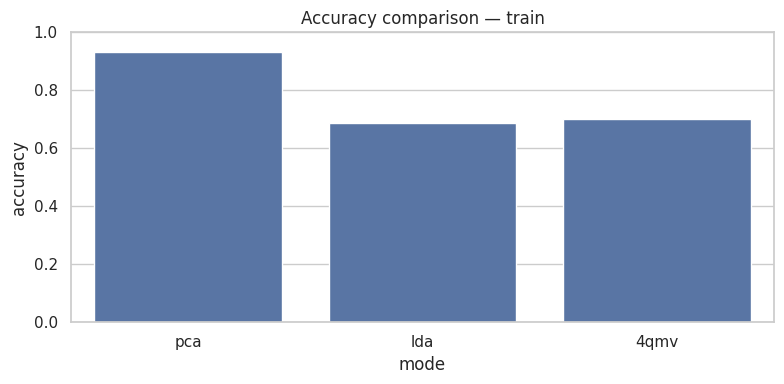

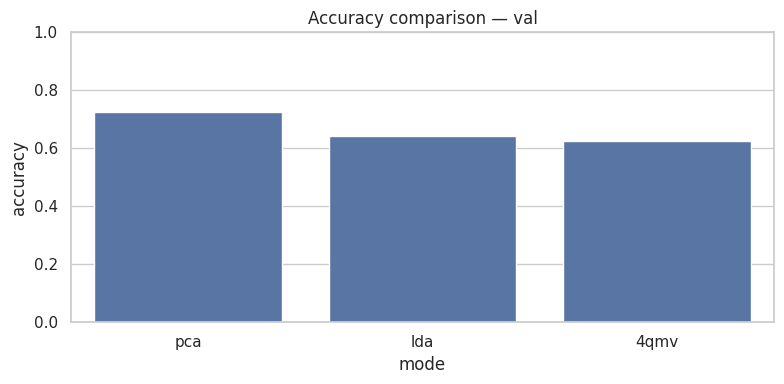

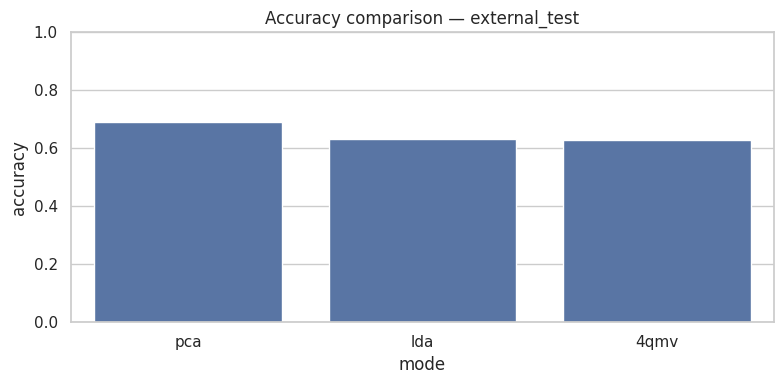

In [22]:
compare_df = pd.concat([pca_summary, lda_summary, qmv_summary], axis=0, ignore_index=True)
display(compare_df.sort_values(['split', 'accuracy'], ascending=[True, False]))

for split_name in ['train', 'val', 'external_test']:
    plt.figure(figsize=(8, 4))
    tmp = compare_df[compare_df['split'] == split_name].copy()
    sns.barplot(data=tmp, x='mode', y='accuracy', order=['pca', 'lda', '4qmv'])
    plt.ylim(0, 1)
    plt.title(f'Accuracy comparison — {split_name}')
    plt.tight_layout()
    plt.show()
